<h1 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">ImmoEliza Project</h1>  
<h2 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px;">ML content</h2>

<h3 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">4 -  Model Comparison</h3>  
<u><h3 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px; margin-bottom: 0px; padding-bottom: 0px;">Regression Models</h3></u>

In [1]:
# import libraries 

import os

import numpy as np
import pandas as pd
import dataframe_image as dfi
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from metrics_utils import calculate_metrics

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries setup complete.")

✅ Libraries setup complete.


In [2]:
# file location dygnosis
print(f"⚠️ Python is reading from here:\n{os.getcwd()}.")

⚠️ Python is reading from here:
d:\Irene\Desktop\AI_&_Data_Science_training_BeCode\BeCode Projects\Preparation-for-Sprint-3-IMMO-ELIZA-Project\4_Model_Comparison.


In [3]:
# importing features train and test preprocessed datasets

PROP_TRAIN_PREPROC_CSV_PATH = "../data/cleaned/properties_train_preprocessed.csv"
PROP_TEST_PREPROC_CSV_PATH = "../data/cleaned/properties_test_preprocessed.csv"
Y_TRAIN_CSV_PATH = "../data/raw/train_test/y_train.csv"
Y_TEST_CSV_PATH = "../data/raw/train_test/y_test.csv"

feature_train = pd.read_csv(PROP_TRAIN_PREPROC_CSV_PATH)
feature_test = pd.read_csv(PROP_TEST_PREPROC_CSV_PATH)

target_train = pd.read_csv(Y_TRAIN_CSV_PATH)
target_test = pd.read_csv(Y_TEST_CSV_PATH)

print("✅ Preprocessed dataset for Train 'properties_train' successfully loaded.")
print("✅ Preprocessed dataset for Test 'properties_test' successfully loaded.")
print("✅ Target dataset for Train 'target_train' successfully loaded.")
print("✅ Target dataset for Test 'target_test' successfully loaded.")

✅ Preprocessed dataset for Train 'properties_train' successfully loaded.
✅ Preprocessed dataset for Test 'properties_test' successfully loaded.
✅ Target dataset for Train 'target_train' successfully loaded.
✅ Target dataset for Test 'target_test' successfully loaded.


In [4]:
# directory for generated charts
CHARTS_DIR_PATH = "../images/charts"

# directory for generated plots
PLOTS_DIR_PATH = "../images/plots"

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">4.1 - 
Framework Definition and Evaluation</h3>

Writing of a function to train, predict and calculate metrics, returning them as a dictionary with also metrics from the baseline.

In [5]:
# statement of dictionary containing metrics from all investigated models
# starting with Ridge from Baseline as constants

models_metrics = {
    'Ridge (Baseline)': {
        'Train R²': '51.78 %', 'Test R²': '44.07 %',
        'Train MAE': '129,456.09 €', 'test MAE': '127,961.77 €'
    }
}

In [6]:
# function for updating return of calculate_metrics function with next models results

def update_metrics_results(model, model_name, X_train, X_test, y_train, y_test):
    '''
    Trains, predicts and calculates new model metrics.
    Returns models_metrics dictionary updated with new model metrics.
    '''
    # training
    model.fit(X_train, y_train) 

    # prediction
    y_prediction_train = model.predict(X_train)
    y_prediction_test = model.predict(X_test)

    # calculate metrics by invoking calculate_metrics function in  metrics_utils.py
    metrics_train = calculate_metrics(y_train, y_prediction_train)
    metrics_test = calculate_metrics(y_test, y_prediction_test)

    # updating models_metrics dictionary
    models_metrics[model_name] = {
        'Train R²': metrics_train['R²'], 'Test R²': metrics_test['R²'],
        'Train MAE': metrics_train['MAE'], 'test MAE': metrics_test['MAE']
    }

    return models_metrics

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">4.2 - Decision Tree Regressor</h3>

In [7]:
# ======== TRAIN ========
# X_train = feature_train
# y_train = target_train

# ======== TEST ========
# X_test = feature_test
# y_test = target_test

# decision tree regressor Inizialization
# Pruning with max_depth (between 5 and 8) - geometrical limits on trees growth
decision_tree_reg = DecisionTreeRegressor(max_depth=8, random_state=42)

update_metrics_results(decision_tree_reg, 'Decision Tree', feature_train, feature_test, target_train, target_test)

{'Ridge (Baseline)': {'Train R²': '51.78 %',
  'Test R²': '44.07 %',
  'Train MAE': '129,456.09 €',
  'test MAE': '127,961.77 €'},
 'Decision Tree': {'Train R²': '71.22 %',
  'Test R²': '51.28 %',
  'Train MAE': '114,311.94 €',
  'test MAE': '127,462.09 €'}}

- first attempt gives **overfitting** &rarr; go back and apply **Pruning**  
- second attempt, max_depth=5: Train R²: 57.0 %, Test R²: 44.04 %  
- <span style="color:green;">third attempt, max_depth=8: Train R²: 71.22 %, Test R²: 51.28 %</span>

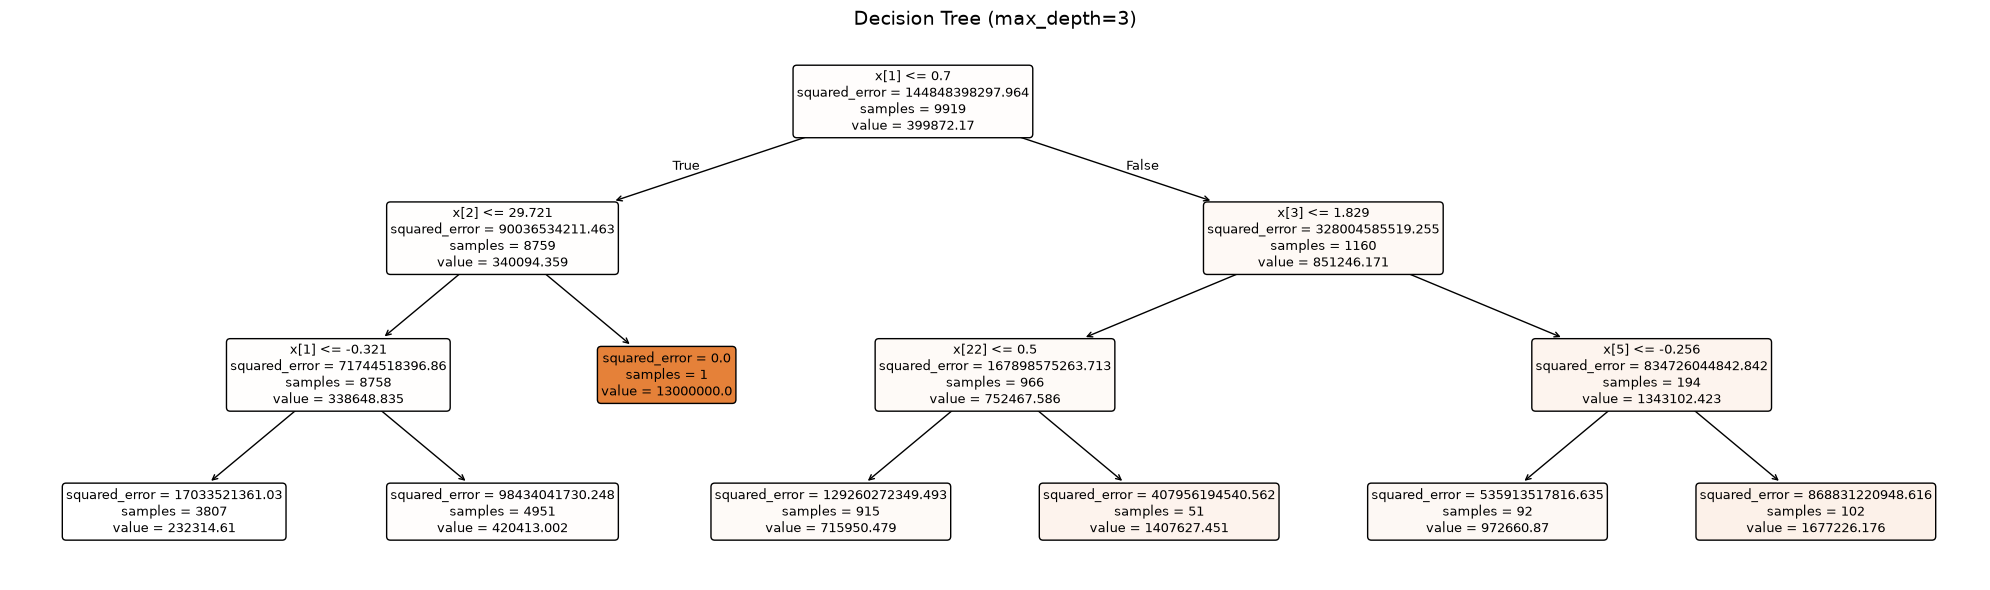

In [8]:
# plotting tree
dt_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_shallow.fit(feature_train, target_train)

plt.figure(figsize=(20,6))
plot_tree(dt_shallow, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR_PATH}/decision_tree_vis.png", bbox_inches='tight', dpi=330)
plt.show()

- Pruning limits performance on Train, but increments model generalization capability on new data.  

- "decent" (block-based) pattern, inevitably produces gross errors at decision boundaries &rarr; move on with **Random Forest** (combination of many different trees, each one splits the dataset at slightly different points, and by averaging their steps, the cloud of points is "smoothed out," transforming rigid blocks into a fluid, continuous curve.)


<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">4.3 - Random Forest Regressor</h3>  

### Key hyperparameters
| Parameter | Description |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth of each tree |
| `max_features` | Number of features to consider at each split |
| `min_samples_leaf` | Minimum samples required at a leaf node |

In [9]:
# random forest regressor Inizialization
# set number of trees to 100
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)

update_metrics_results(rf_reg, 'Random Forest', feature_train, feature_test, target_train, target_test)

{'Ridge (Baseline)': {'Train R²': '51.78 %',
  'Test R²': '44.07 %',
  'Train MAE': '129,456.09 €',
  'test MAE': '127,961.77 €'},
 'Decision Tree': {'Train R²': '71.22 %',
  'Test R²': '51.28 %',
  'Train MAE': '114,311.94 €',
  'test MAE': '127,462.09 €'},
 'Random Forest': {'Train R²': '94.28 %',
  'Test R²': '69.83 %',
  'Train MAE': '35,313.93 €',
  'test MAE': '90,309.42 €'}}

- first attempt (n_estimators=100): Train R²: 94.24 %, Test R²: 69.25 %  
- <span style="color:green;">second attempt (n_estimators=200): Train R²: 94.28 %, Test R²: 69.83 %</span>  
- third attempt (n_estimators=500): Train R²: 94.56 %, Test R²: 69.88 % &rarr; profit on model performance not worth the time consumed (1m 30s).  

Train R² remains unchanged across all three attempts. &rarr; Increasing the number of trees (<code>n_estimators</code>) does not cure overfitting and does not reduce model bias.  
Random Forest reduces variance by aggregating multiple estimates, but if the underlying tree structure is too deep, the training error will remain far removed from the test error, regardless of how many trees we set.

<i>Good idea is to plot r2_test with increasing n_estimators to evaluate the benefits.</i>

**Feature Importance**

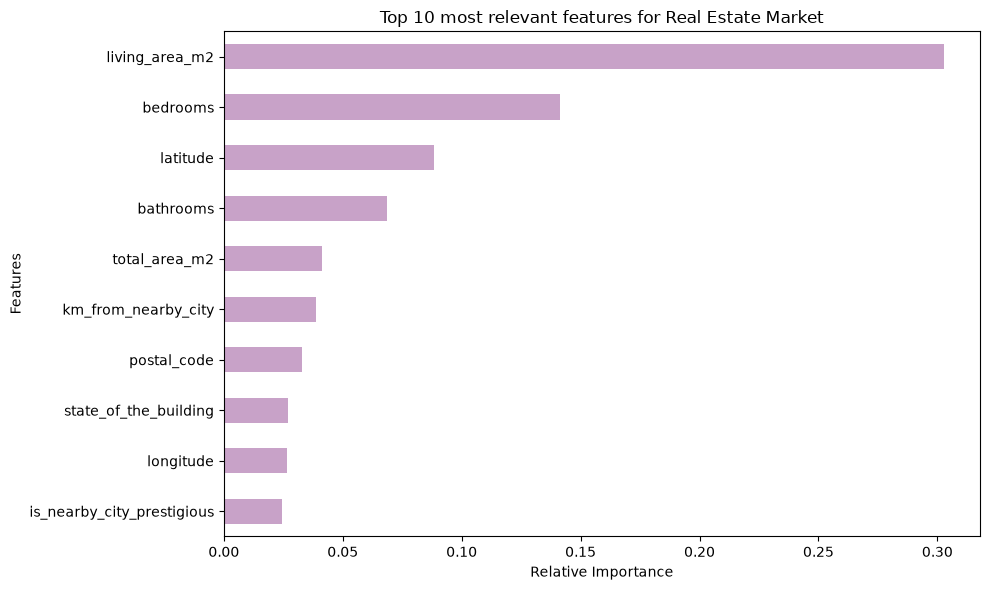

In [10]:
# creating a Series coupling importance values to columns names
importances = pd.Series(rf_reg.feature_importances_, index=feature_train.columns)

# isolating and sorting 10 biggest importance values between them
top_10_features = importances.nlargest(10).sort_values(ascending=True)

# bar graph
plt.figure(figsize=(10,6))
top_10_features.plot(kind='barh', color='#c8a2c8')
plt.title('Top 10 most relevant features for Real Estate Market')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR_PATH}/top_10_most_relevant_feat.png", bbox_inches='tight', dpi=330)
plt.show()


<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">4.4 - XGBoost Regressor</h3>  

Instead of training trees *independently* (like Random Forest), it trains them **sequentially** — each new tree tries to correct the errors of the previous ones. This is called **gradient boosting**.  

### Key hyperparameters
| Parameter | Description |
|---|---|
| `n_estimators` | Number of boosting rounds (trees) |
| `learning_rate` | Shrinks the contribution of each tree (lower = slower but more robust) |
| `max_depth` | Maximum depth of each tree |
| `subsample` | Fraction of training samples used per tree |
| `colsample_bytree` | Fraction of features used per tree |

In [12]:
# XGBoost regressor Inizialization
# set number of boosting rounds to 100
xgb_reg = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42,
    verbosity=1
)

update_metrics_results(xgb_reg, 'XGBoost', feature_train, feature_test, target_train, target_test)

{'Ridge (Baseline)': {'Train R²': '51.78 %',
  'Test R²': '44.07 %',
  'Train MAE': '129,456.09 €',
  'test MAE': '127,961.77 €'},
 'Decision Tree': {'Train R²': '71.22 %',
  'Test R²': '51.28 %',
  'Train MAE': '114,311.94 €',
  'test MAE': '127,462.09 €'},
 'Random Forest': {'Train R²': '94.28 %',
  'Test R²': '69.83 %',
  'Train MAE': '35,313.93 €',
  'test MAE': '90,309.42 €'},
 'XGBoost': {'Train R²': '90.27 %',
  'Test R²': '73.13 %',
  'Train MAE': '67,934.74 €',
  'test MAE': '89,801.56 €'}}

- <span style="color:green;">first attempt (learning_rate=0.1): Train R²: 90.27 %, Test R²: 73.13 %</span> &rarr; 17.14% margin
- second attempt (learning_rate=0.01): Train R²: 56.92 %, Test R²: 50.63 %
- third attempt (learning_rate=0.01): Train R²: 84.72 %, Test R²: 70.93 % &rarr; 13.79% margin


I can now move on to the **Model Optimization** phase of the project.

In [13]:
# generate and save chart with metrics results obtained from models_metrics dictionary

def gen_save_metrics_chart(metrics_dict):

    # converting dict to a Pandas df
    df_comparison = pd.DataFrame(metrics_dict)
    # switch rows and columns
    df_comparison = df_comparison.T

    fig, ax = plt.subplots(figsize=(10, len(df_comparison) * 0.6 + 1))
    ax.axis('off')

    table = ax.table(
        cellText=df_comparison.values,
        colLabels=df_comparison.columns,
        rowLabels=df_comparison.index,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)

    # saving location
    os.makedirs(CHARTS_DIR_PATH, exist_ok=True)

    # save chart
    file_name = "model_comparison_results.png"
    plt.savefig(f"{CHARTS_DIR_PATH}/{file_name}", bbox_inches='tight', dpi=330)
    plt.close()

    return f'✅ Chart successfully saved in {CHARTS_DIR_PATH} as {file_name}.'

In [14]:
print(gen_save_metrics_chart(models_metrics))

✅ Chart successfully saved in ../images/charts as model_comparison_results.png.
